In [1]:
import pennylane as qml
import torch
import torch.nn as nn 
import numpy as np 
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

def make_quantum_circuite(n_qubit,n_layers,circuite_id):
    dev = qml.device("default.qubit",wires=n_qubit)
    
    @qml.qnode(dev,interface='torch',diff_method='backprop') # optimise by 'backproo' is very faster than 'parameter_shift' for simulation.
    def circuit(inputs,weights):
        qml.AngleEmbedding(inputs,wires=range(n_qubit),rotation='X')
        
        qml.StronglyEntanglingLayers(weights,wires=range(n_qubit))
        
        return [qml.expval(qml.PauliY(i)) for i in range(n_qubit)]
    
    return circuit
    

In [2]:
class ParallelQuantumLayer(nn.Module):
    def __init__(self, n_qubit, n_layer, n_circuits, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.q = n_qubit
        self.i = n_layer
        self.c = n_circuits
        
        weight_shapes = {'weights': (n_layer, n_qubit, 3)}
        
        # تعریف مدارها
        self.circuts = nn.ModuleList()
        for k in range(n_circuits):
            # دقت کن که در make_quantum_circuite حتما از "lightning.qubit" و diff_method="adjoint" استفاده کرده باشی
            circ = make_quantum_circuite(n_qubit, n_layer, k)
            qlayer = qml.qnn.TorchLayer(circ, weight_shapes)
            self.circuts.append(qlayer)
            
    def forward(self, x):
        # x shape: (batch, n_circuits * n_qubit)
        original_device = x.device
        x = x.cpu()

        # جدا کردن ورودی‌ها برای هر مدار به صورت لیستی
        # این کار سریع‌تر از اسلایس کردن داخل حلقه است
        inputs = torch.split(x, self.q, dim=1)
        
        output = []
        for k, qlayer in enumerate(self.circuts):
            # اجرای لایه (PennyLane در پس‌زمینه اگر بتواند این‌ها را Batch می‌کند)
            out_k = qlayer(inputs[k])
            output.append(out_k)
            
        # اتصال خروجی‌ها
        return torch.cat(output, dim=1).to(original_device)


In [ ]:
def make_quantum_circuite(n_qubit,n_layers,circuite_id):
    dev = qml.device("default.qubit",wires=n_qubit)
    
    @qml.qnode(dev,interface='torch',diff_method='backprop') # optimise by 'backproo' is very faster than 'parameter_shift' for simulation.
    def circuit(inputs,weights):
        qml.AngleEmbedding(inputs,wires=range(n_qubit),rotation='X')
        
        qml.StronglyEntanglingLayers(weights,wires=range(n_qubit))
        
        return [qml.expval(qml.PauliY(i)) for i in range(n_qubit)]
    
    return circuit

In [4]:
class classiacNN(nn.Module):
    """ 
     Fully classical version ofHQNN-parallel MNIST(28*28,10 class)
     
     Hyoerparameters (maching hyper model):
     n = 20 ()
     n_class = 10
    """
    
    def __init__(self,n=20,n_class=10, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n = n
                # ── Convolutional Block 1 ──────────────────────────────
        # Input:  (B, 1, 28, 28)
        # Conv:   kernel=5, pad=2, stride=1 → (B, 16, 28, 28)
        # MaxPool: kernel=2 → (B, 16, 14, 14)
        
        self.conv_black1 = nn.Sequential(
            nn.Conv2d(1,16,kernel_size=5,stride=1,padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
                # ── Convolutional Block 2 ──────────────────────────────
        # Input:  (B, 16, 14, 14)
        # Conv:   kernel=5, pad=2, stride=1 → (B, 32, 14, 14)
        # MaxPool: kernel=2 → (B, 32, 7, 7)
        
        self.conv_black2 = nn.Sequential(
            nn.Conv2d(16,32,kernel_size=5,stride=1,padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Flatten: 32 * 7 * 7 = 1568
        
        # ── Dense Layer 1 (classical) ──────────────────────────
        # 1568 → n (20)
        
        self.fc1 = nn.Sequential(
            nn.Linear(1568,self.n),  # self.n is input in Quantum Layers on Hybrid model
            nn.BatchNorm1d(self.n),
            nn.ReLU()
        )
        
        self.classical_layer = nn.Sequential(
            nn.Linear(self.n, self.n),
            nn.BatchNorm1d(self.n),
            nn.ReLU()
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(self.n, self.n),
            nn.BatchNorm1d(self.n),
            nn.ReLU()
        )
        
    def forward(self, x):
        x = self.conv_black1(x)
        x = self.conv_black2(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.classical_layer(x)  # Classical replacement
        x = self.fc2(x)
        return x        

In [5]:
#Load dataset 

trasform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=trasform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=trasform
)

train_Loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_Loader = DataLoader(train_dataset,batch_size=32,shuffle=True)




In [6]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())


2.7.1+cu118
11.8
True


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_hybrid = HQNNParaleem().to(device)

optimiser_hybrid = optim.Adam(model_hybrid.parameters(),lr=1e-3)  # Adam is SGD by a momentum in first
criterion = nn.CrossEntropyLoss() # L = yLog(y^) + (1-y)log(1-y^) y : lables and y^ : prediction 

#print(model)
print(f'Device:{device}')
print(model_hybrid.quantum_layer)
for i,circut in enumerate(model_hybrid.quantum_layer.circuts):
   print(f'\nCircuts {i}')   
   for name, param in model_hybrid.quantum_layer.named_parameters():
      print(name,param.shape)
for i in model_hybrid.parameters():
   # print(f'{i}')
   pass
sum(p.numel() for p in model_hybrid.quantum_layer.parameters())



Device:cuda
ParallelQuantumLayer(
  (circuts): ModuleList(
    (0-3): 4 x <Quantum Torch Layer: func=circuit>
  )
)

Circuts 0
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])

Circuts 1
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])

Circuts 2
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])

Circuts 3
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])


180

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_classic = classiacNN().to(device)

optimiser_classic = optim.Adam(model_classic.parameters(),lr=1e-3)  # Adam is SGD by a momentum in first
criterion = nn.CrossEntropyLoss()

print(f'Device: {device}')
print(f'Model: Classical NN')
print(f'Total parameters: {sum(p.numel() for p in model_classic.parameters())}')

Device: cuda
Model: Classical NN
Total parameters: 45684


In [9]:
sum(p.numel() for p in model_hybrid.quantum_layer.parameters())


180

In [10]:
# train

def train_epoch(model,loader,optimiser,criterion,device):
    model.train()
    total_loss ,correct = 0,0
    for batch_idx,(data,target) in enumerate(loader):
        data,target = data.to(device),target.to(device)
        optimiser.zero_grad()
        output = model(data)
        loss = criterion(output,target)
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
        correct += output.argmax(1).eq(target).sum().item() # correct = zigma(y^i = yi)
        if batch_idx % 500 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}")
    return total_loss / len(loader), correct / len(loader.dataset)
        

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += criterion(output, target).item()
            correct += output.argmax(1).eq(target).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [12]:
history = {
    'hybrid': {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []},
    'classical': {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
}

In [71]:
n_epoch = 5

for epoch in range(1, n_epoch + 1):
    tr_loss, tr_acc = train_epoch(model_classic, train_Loader, optimiser_classic, criterion, device)
    te_loss, te_acc = evaluate(model_classic, test_Loader, criterion, device)
    history['classical']['train_loss'].append(tr_loss)
    history['classical']['test_loss'].append(te_loss)
    history['classical']['train_acc'].append(tr_acc * 100)
    history['classical']['test_acc'].append(te_acc * 100)
    print(f"Epoch {epoch}/{n_epoch} | Train Loss: {tr_loss:.4f} | Test Acc: {te_acc*100:.2f}%")


  Batch 0/1875 | Loss: 3.0970
  Batch 500/1875 | Loss: 0.4838
  Batch 1000/1875 | Loss: 0.3670
  Batch 1500/1875 | Loss: 0.1657
Epoch 1/5 | Train Loss: 0.4877 | Test Acc: 98.83%
  Batch 0/1875 | Loss: 0.1198
  Batch 500/1875 | Loss: 0.1544
  Batch 1000/1875 | Loss: 0.1015
  Batch 1500/1875 | Loss: 0.1174
Epoch 2/5 | Train Loss: 0.1612 | Test Acc: 99.13%
  Batch 0/1875 | Loss: 0.3063
  Batch 500/1875 | Loss: 0.0423
  Batch 1000/1875 | Loss: 0.0666
  Batch 1500/1875 | Loss: 0.2744
Epoch 3/5 | Train Loss: 0.1040 | Test Acc: 99.09%
  Batch 0/1875 | Loss: 0.0912
  Batch 500/1875 | Loss: 0.2220
  Batch 1000/1875 | Loss: 0.0248
  Batch 1500/1875 | Loss: 0.0143
Epoch 4/5 | Train Loss: 0.0739 | Test Acc: 99.47%
  Batch 0/1875 | Loss: 0.0321
  Batch 500/1875 | Loss: 0.1688
  Batch 1000/1875 | Loss: 0.0906
  Batch 1500/1875 | Loss: 0.0175
Epoch 5/5 | Train Loss: 0.0586 | Test Acc: 99.50%


In [72]:
n_epoch = 5

for epoch in range(1,n_epoch+1):
    print(f'\nEpoch {epoch}/ {n_epoch}')
    train_loss,trainacc = train_epoch(model_hybrid,train_Loader,optimiser_hybrid,criterion,device)
    test_loss,  test_acc  = evaluate(model_hybrid, test_Loader, criterion, device)
    history['hybrid']['train_loss'].append(train_loss)
    history['hybrid']['test_loss'].append(test_loss)
    history['hybrid']['train_acc'].append(trainacc * 100)
    history['hybrid']['test_acc'].append(test_acc * 100)
    print(f"Epoch {epoch}/{n_epoch} | Train Loss: {train_loss:.4f} | Test Acc: {te_acc*100:.2f}%")



Epoch 1/ 5
  Batch 0/1875 | Loss: 2.2993
  Batch 500/1875 | Loss: 0.4232
  Batch 1000/1875 | Loss: 0.1140
  Batch 1500/1875 | Loss: 0.0216
Epoch 1/5 | Train Loss: 0.4306 | Test Acc: 99.50%

Epoch 2/ 5
  Batch 0/1875 | Loss: 0.0571
  Batch 500/1875 | Loss: 0.0459
  Batch 1000/1875 | Loss: 0.0126
  Batch 1500/1875 | Loss: 0.0118
Epoch 2/5 | Train Loss: 0.0621 | Test Acc: 99.50%

Epoch 3/ 5
  Batch 0/1875 | Loss: 0.0901
  Batch 500/1875 | Loss: 0.0058
  Batch 1000/1875 | Loss: 0.1069
  Batch 1500/1875 | Loss: 0.0236
Epoch 3/5 | Train Loss: 0.0420 | Test Acc: 99.50%

Epoch 4/ 5
  Batch 0/1875 | Loss: 0.0152
  Batch 500/1875 | Loss: 0.0044
  Batch 1000/1875 | Loss: 0.0031
  Batch 1500/1875 | Loss: 0.0034
Epoch 4/5 | Train Loss: 0.0332 | Test Acc: 99.50%

Epoch 5/ 5
  Batch 0/1875 | Loss: 0.0111
  Batch 500/1875 | Loss: 0.0088
  Batch 1000/1875 | Loss: 0.0591
  Batch 1500/1875 | Loss: 0.0096
Epoch 5/5 | Train Loss: 0.0284 | Test Acc: 99.50%


In [13]:
import os 
import torch
import json
from datetime import datetime


In [85]:
save_dir = './save_models'
os.makedirs(save_dir,exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def save_full_checkpoint(model,optimizer,history,name,save_dir):
    path = os.path.join(save_dir,f'{name}-{timestamp}.path')
    torch.save({        
                # Model
        'model_state_dict':      model.state_dict(),
        'model_class':           model.__class__.__name__,
       # 'model_full':            model,                        # کل آبجکت مدل

        # Optimizer
        'optimizer_state_dict':  optimizer.state_dict(),
        'optimizer_class':       optimizer.__class__.__name__,

        # Training State
      #  'epoch':                 epoch,
        'history':               history,

        # Metadata
        'timestamp':             timestamp,
        'pytorch_version':       torch.__version__,
    }, path)
        
    print(f'saved: {path}')
    return path





In [86]:
path_hybrid = save_full_checkpoint(
    model= model_hybrid,
    optimizer= optimiser_hybrid,
    history= history['hybrid'],
   # epoch= len(history['hybrid']['test_loss'])
    name = 'HQNN_hybrid',
    save_dir= save_dir
)

path_classical = save_full_checkpoint(
    model     = model_classic,
    optimizer = optimiser_classic,
    history   = history['classical'],
    #epoch     = len(history['classical']['test_loss']),
    name      = "ClassicalNN",
    save_dir  = save_dir
)

saved: ./save_models\HQNN_hybrid-20260616_121424.path
saved: ./save_models\ClassicalNN-20260616_121424.path


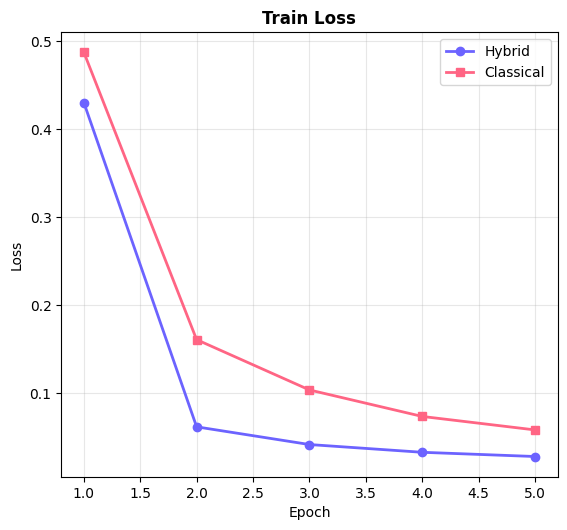

In [98]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

colors = {'hybrid': '#6C63FF', 'classical': '#FF6584'}
epochs = list(range(1, len(history['hybrid']['train_loss']) + 1))

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history['hybrid']['train_loss'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax1.plot(epochs, history['classical']['train_loss'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax1.set_title('Train Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


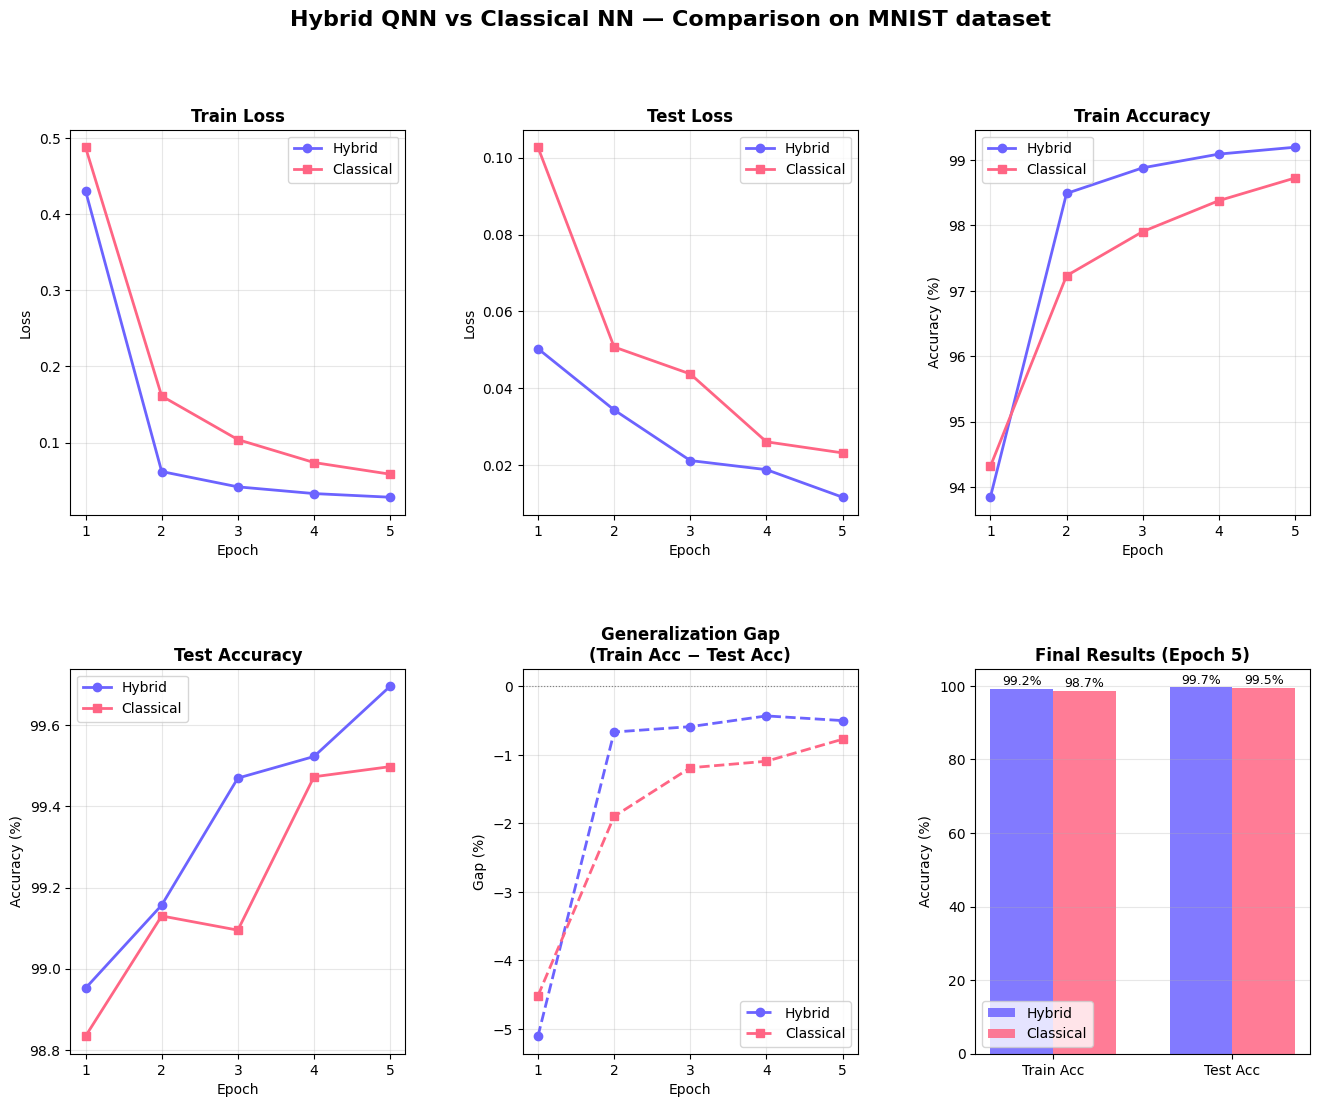


Plot saved as 'hybrid_vs_classical.png'


In [ ]:
epochs = range(1, n_epoch + 1)

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Hybrid QNN vs Classical NN — Comparison on MNIST dataset', fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = {'hybrid': '#6C63FF', 'classical': '#FF6584'}

# ── Plot 1: Train Loss ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history['hybrid']['train_loss'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax1.plot(epochs, history['classical']['train_loss'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax1.set_title('Train Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: Test Loss ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, history['hybrid']['test_loss'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax2.plot(epochs, history['classical']['test_loss'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax2.set_title('Test Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Plot 3: Train Accuracy ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, history['hybrid']['train_acc'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax3.plot(epochs, history['classical']['train_acc'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax3.set_title('Train Accuracy', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── Plot 4: Test Accuracy ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs, history['hybrid']['test_acc'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax4.plot(epochs, history['classical']['test_acc'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax4.set_title('Test Accuracy', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ── Plot 5: Generalization Gap (Train Acc - Test Acc) ──────
ax5 = fig.add_subplot(gs[1, 1])
gap_hybrid    = [tr - te for tr, te in zip(history['hybrid']['train_acc'],    history['hybrid']['test_acc'])]
gap_classical = [tr - te for tr, te in zip(history['classical']['train_acc'], history['classical']['test_acc'])]
ax5.plot(epochs, gap_hybrid,    color=colors['hybrid'],    marker='o', linewidth=2, linestyle='--', label='Hybrid')
ax5.plot(epochs, gap_classical, color=colors['classical'], marker='s', linewidth=2, linestyle='--', label='Classical')
ax5.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax5.set_title('Generalization Gap\n(Train Acc − Test Acc)', fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Gap (%)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# ── Plot 6: Final Epoch Bar Chart ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
metrics     = ['Train Acc', 'Test Acc']
hybrid_vals = [history['hybrid']['train_acc'][-1],    history['hybrid']['test_acc'][-1]]
class_vals  = [history['classical']['train_acc'][-1], history['classical']['test_acc'][-1]]
x = np.arange(len(metrics))
width = 0.35
bars1 = ax6.bar(x - width/2, hybrid_vals,  width, label='Hybrid',    color=colors['hybrid'],    alpha=0.85)
bars2 = ax6.bar(x + width/2, class_vals,   width, label='Classical', color=colors['classical'], alpha=0.85)
ax6.set_title(f'Final Results (Epoch {n_epoch})', fontweight='bold')
ax6.set_ylabel('Accuracy (%)')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.savefig('hybrid_vs_classical.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'hybrid_vs_classical.png'")


In [14]:
def count_params(model, name):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Total params     : {total:,}")
    print(f"  Trainable params : {trainable:,}")
    for n, p in model.named_parameters():
        print(f"  {n:<35} {str(tuple(p.shape)):<20} {p.numel():,}")

count_params(model_hybrid,    "HYBRID MODEL")
count_params(model_classic, "CLASSICAL MODEL")



  HYBRID MODEL
  Total params     : 45,154
  Trainable params : 45,154
  conv_black.0.weight                 (16, 1, 5, 5)        400
  conv_black.0.bias                   (16,)                16
  conv_black.1.weight                 (16,)                16
  conv_black.1.bias                   (16,)                16
  conv_black2.0.weight                (32, 16, 5, 5)       12,800
  conv_black2.0.bias                  (32,)                32
  conv_black2.1.weight                (32,)                32
  conv_black2.1.bias                  (32,)                32
  fc1.0.weight                        (20, 1568)           31,360
  fc1.0.bias                          (20,)                20
  fc1.1.weight                        (20,)                20
  fc1.1.bias                          (20,)                20
  quantum_layer.circuts.0.weights     (3, 5, 3)            45
  quantum_layer.circuts.1.weights     (3, 5, 3)            45
  quantum_layer.circuts.2.weights     (3, 5, 3)    

In [15]:
import io, sys, datetime

def save_model_summary(hybrid_model, classical_model, path="model_summary.txt"):
    buffer = io.StringIO()
    
    def count_params(model, name):
        total     = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        buffer.write(f"\n{'='*50}\n")
        buffer.write(f"  {name}\n")
        buffer.write(f"{'='*50}\n")
        buffer.write(f"  Total params     : {total:,}\n")
        buffer.write(f"  Trainable params : {trainable:,}\n")
        buffer.write(f"  {'Layer':<35} {'Shape':<20} {'Params':>10}\n")
        buffer.write(f"  {'-'*65}\n")
        for n, p in model.named_parameters():
            buffer.write(f"  {n:<35} {str(tuple(p.shape)):<20} {p.numel():>10,}\n")

    buffer.write(f"Model Summary Report\n")
    buffer.write(f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    
    count_params(hybrid_model,    "HYBRID MODEL (HQNNParaleem)")
    count_params(classical_model, "CLASSICAL MODEL (ClassicalNN)")

    with open(path, "w", encoding="utf-8") as f:
        f.write(buffer.getvalue())
    
    print(f"Saved to: {path}")

save_model_summary(model_hybrid, model_classic, "model_summary.txt")


Saved to: model_summary.txt


In [16]:
import torchvision.transforms as T # استفاده از نام مستعار برای جلوگیری از تداخل

# نام متغیر را متفاوت انتخاب کن
transform_cifar = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset_cifar = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_cifar # استفاده از نام متغیر جدید
)

test_dataset_cifar = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_cifar
)

train_loader_cifar10 = DataLoader(train_dataset_cifar, batch_size=32, shuffle=True)
test_loader_cifar10 = DataLoader(test_dataset_cifar, batch_size=32, shuffle=False)


In [18]:
train_dataset


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [19]:
train_dataset_cifar

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
           )

In [ ]:
class HQNN_CIFAR(nn.Module):
    """
    HQNN-Parallel for CIFAR-10 (32x32, 10 classes, RGB)
    
    Architecture:
        - ConvBlock 1: (B, 3, 32, 32) -> (B, 32, 16, 16)
        - ConvBlock 2: (B, 32, 16, 16) -> (B, 64, 8, 8)
        - Flatten: 64 * 8 * 8 = 4096
        - FC1: 4096 -> n (20)
        - Parallel Quantum Layer: n -> n
        - FC2: n -> 10
    """
    def __init__(self, n_qubits=5, n_layers=3, n_circuts=4, n_class=10, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n = n_qubits * n_circuts
        
        # ── Convolutional Block 1 ──────────────────────────────
        # Input: (B, 3, 32, 32) - CIFAR images are RGB
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # استفاده از کانال 3
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # Result: (B, 32, 16, 16)
        )
        
        # ── Convolutional Block 2 ──────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # Result: (B, 64, 8, 8)
        )
        
        # محاسبه سایز Flatten: 64 کانال * طول 8 * عرض 8 = 4096
        self.flatten_size = 64 * 8 * 8
        
        # ── Dense Layer 1 (classical) ──────────────────────────
        self.fc1 = nn.Sequential(
            nn.Linear(self.flatten_size, self.n),
            nn.BatchNorm1d(self.n),
            nn.ReLU(),
            nn.Dropout(0.3)
            
        )
        
        # ── Quantum Layer ──────────────────────────────────────
        # این همان کلاسی است که در forward آن x.cpu() را اضافه کردیم
        self.quantum_layer = ParallelQuantumLayer(n_qubits, n_layers, n_circuts)
        
        # ── Dense Layer 2 (classical) ──────────────────────────
        self.fc2 = nn.Sequential(
            nn.Linear(self.n, n_class)
        )
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        x = self.fc1(x)
        
        # لایه کوانتومی (مدیریت جابه‌جایی بین GPU/CPU در داخل این لایه انجام می‌شود)
        x = self.quantum_layer(x)
        
        x = self.fc2(x)
        return x


In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_hybrid_cifar10 = HQNN_CIFAR().to(device)

optimiser_hybrid_cifar10 = optim.Adam(model_hybrid_cifar10.parameters(),lr=1e-3,weight_decay=1e-4)  # Adam is SGD by a momentum in first
criterion = nn.CrossEntropyLoss() # L = yLog(y^) + (1-y)log(1-y^) y : lables and y^ : prediction 

schedulear = torch.optim.lr_scheduler.ReduceLROnPlateau(
   optimizer=optimiser_hybrid_cifar10,
   mode='min',
   factor=0.5,
   patience=2,
   min_lr=1e-6
)

#print(model)
print(f'Device:{device}')
print(model_hybrid_cifar10.quantum_layer)
for i,circut in enumerate(model_hybrid_cifar10.quantum_layer.circuts):
   print(f'\nCircuts {i}')   
   for name, param in model_hybrid_cifar10.quantum_layer.named_parameters():
      print(name,param.shape)
for i in model_hybrid.parameters():
   # print(f'{i}')
   pass
sum(p.numel() for p in model_hybrid_cifar10.quantum_layer.parameters())


Device:cuda
ParallelQuantumLayer(
  (circuts): ModuleList(
    (0-3): 4 x <Quantum Torch Layer: func=circuit>
  )
)

Circuts 0
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])

Circuts 1
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])

Circuts 2
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])

Circuts 3
circuts.0.weights torch.Size([3, 5, 3])
circuts.1.weights torch.Size([3, 5, 3])
circuts.2.weights torch.Size([3, 5, 3])
circuts.3.weights torch.Size([3, 5, 3])


180

In [22]:
history_cifar10 = {
    'hybrid': {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []},
    'classical': {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
}

In [58]:
class ClassicalNN_CIFAR(nn.Module):
    """
    Fully Classical baseline for HQNN (CIFAR‑10)

    Input: 3x32x32
    Architecture matched with hybrid model for fair comparison
    """

    def __init__(self, n=20, n_class=10, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n = n

        # ── Convolutional Block 1 ──────────────────────────────
        # (B,3,32,32) -> (B,16,16,16)
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # ── Convolutional Block 2 ──────────────────────────────
        # (B,16,16,16) -> (B,32,8,8)
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Flatten size
        self.flatten_dim = 32 * 8 * 8  # 2048

        # ── Dense Layer 1 ──────────────────────────
        self.fc1 = nn.Sequential(
            nn.Linear(self.flatten_dim, self.n),
            nn.BatchNorm1d(self.n),
            nn.ReLU(),
            #nn.Dropout(0.3)

        )

        # Classical replacement of quantum layer
        self.classical_layer = nn.Sequential(
            nn.Linear(self.n, self.n),
            nn.BatchNorm1d(self.n),
            nn.ReLU(),
            #nn.Dropout(0.3)

        )

        # Output layer
        self.fc2 = nn.Linear(self.n, n_class)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)

        x = x.view(x.size(0), -1)  # Flatten

        x = self.fc1(x)
        x = self.classical_layer(x)
        x = self.fc2(x)

        return x


In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_classic_cifar10 = ClassicalNN_CIFAR().to(device)

optimiser_classic_cifar10 = optim.Adam(model_classic_cifar10.parameters(),lr=1e-3)  # Adam is SGD by a momentum in first
criterion = nn.CrossEntropyLoss()
schedulear = torch.optim.lr_scheduler.ReduceLROnPlateau(
   optimizer=optimiser_hybrid_cifar10,
   mode='min',
   factor=0.7,
   patience=3,
   min_lr=1e-6
)
print(f'Device: {device}')
print(f'Model: Classical NN')
print(f'Total parameters: {sum(p.numel() for p in model_classic_cifar10.parameters())}')

Device: cuda
Model: Classical NN
Total parameters: 55834


In [45]:


n_epoch = 12

for epoch in range(1, n_epoch + 1):
    tr_loss, tr_acc = train_epoch(model_classic_cifar10, train_loader_cifar10, optimiser_classic_cifar10, criterion, device)
    te_loss, te_acc = evaluate(model_classic_cifar10, test_loader_cifar10, criterion, device)    
    schedulear.step(test_loss)

    history_cifar10['classical']['train_loss'].append(tr_loss)
    history_cifar10['classical']['test_loss'].append(te_loss)
    history_cifar10['classical']['train_acc'].append(tr_acc * 100)
    history_cifar10['classical']['test_acc'].append(te_acc * 100)
    current_lr = optimiser_hybrid_cifar10.param_groups[0]['lr']

    print(f"Epoch {epoch}/{n_epoch} | Train Loss: {tr_loss:.4f} | Test Acc: {te_acc*100:.2f}% |LR: {current_lr:.6f}")


  Batch 0/1563 | Loss: 0.9857
  Batch 500/1563 | Loss: 0.8360
  Batch 1000/1563 | Loss: 0.7330
  Batch 1500/1563 | Loss: 1.3504
Epoch 1/12 | Train Loss: 0.8889 | Test Acc: 71.84% |LR: 0.000250
  Batch 0/1563 | Loss: 0.7294
  Batch 500/1563 | Loss: 1.2686
  Batch 1000/1563 | Loss: 1.0573
  Batch 1500/1563 | Loss: 0.7410
Epoch 2/12 | Train Loss: 0.8765 | Test Acc: 71.98% |LR: 0.000250
  Batch 0/1563 | Loss: 0.5936
  Batch 500/1563 | Loss: 1.2008
  Batch 1000/1563 | Loss: 1.0242
  Batch 1500/1563 | Loss: 0.8459
Epoch 3/12 | Train Loss: 0.8710 | Test Acc: 72.22% |LR: 0.000125
  Batch 0/1563 | Loss: 0.8653
  Batch 500/1563 | Loss: 0.5477
  Batch 1000/1563 | Loss: 0.8461
  Batch 1500/1563 | Loss: 1.0588
Epoch 4/12 | Train Loss: 0.8535 | Test Acc: 72.49% |LR: 0.000125
  Batch 0/1563 | Loss: 0.6722
  Batch 500/1563 | Loss: 0.9068
  Batch 1000/1563 | Loss: 0.7799
  Batch 1500/1563 | Loss: 0.7094
Epoch 5/12 | Train Loss: 0.8501 | Test Acc: 72.70% |LR: 0.000125
  Batch 0/1563 | Loss: 0.8359
  Bat

In [42]:
n_epoch = 12

for epoch in range(1,n_epoch+1):
    print(f'\nEpoch {epoch}/ {n_epoch}')
    train_loss,trainacc = train_epoch(model_hybrid_cifar10,train_loader_cifar10,optimiser_hybrid_cifar10,criterion,device)
    test_loss,  test_acc  = evaluate(model_hybrid_cifar10, test_loader_cifar10, criterion, device)
    schedulear.step(test_loss)

    history_cifar10['hybrid']['train_loss'].append(train_loss)
    history_cifar10['hybrid']['test_loss'].append(test_loss)
    history_cifar10['hybrid']['train_acc'].append(trainacc * 100)
    history_cifar10['hybrid']['test_acc'].append(test_acc * 100)
    current_lr = optimiser_hybrid_cifar10.param_groups[0]['lr']

    print(f"Epoch {epoch}/{n_epoch} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc*100:.2f}% |LR: {current_lr:.6f}")


Epoch 1/ 12
  Batch 0/1563 | Loss: 2.2729
  Batch 500/1563 | Loss: 1.6140
  Batch 1000/1563 | Loss: 1.1852
  Batch 1500/1563 | Loss: 1.2299
Epoch 1/12 | Train Loss: 1.5259 | Test Acc: 59.81% |LR: 0.001000

Epoch 2/ 12
  Batch 0/1563 | Loss: 1.2023
  Batch 500/1563 | Loss: 0.9544
  Batch 1000/1563 | Loss: 0.7733
  Batch 1500/1563 | Loss: 1.1676
Epoch 2/12 | Train Loss: 1.0505 | Test Acc: 66.73% |LR: 0.001000

Epoch 3/ 12
  Batch 0/1563 | Loss: 0.6774
  Batch 500/1563 | Loss: 1.0875
  Batch 1000/1563 | Loss: 0.6534
  Batch 1500/1563 | Loss: 1.1488
Epoch 3/12 | Train Loss: 0.8884 | Test Acc: 70.07% |LR: 0.001000

Epoch 4/ 12
  Batch 0/1563 | Loss: 0.6338
  Batch 500/1563 | Loss: 0.8163
  Batch 1000/1563 | Loss: 0.9132
  Batch 1500/1563 | Loss: 0.9643
Epoch 4/12 | Train Loss: 0.7869 | Test Acc: 70.98% |LR: 0.001000

Epoch 5/ 12
  Batch 0/1563 | Loss: 0.8377
  Batch 500/1563 | Loss: 0.8035
  Batch 1000/1563 | Loss: 0.7038
  Batch 1500/1563 | Loss: 0.6189
Epoch 5/12 | Train Loss: 0.7141 | T

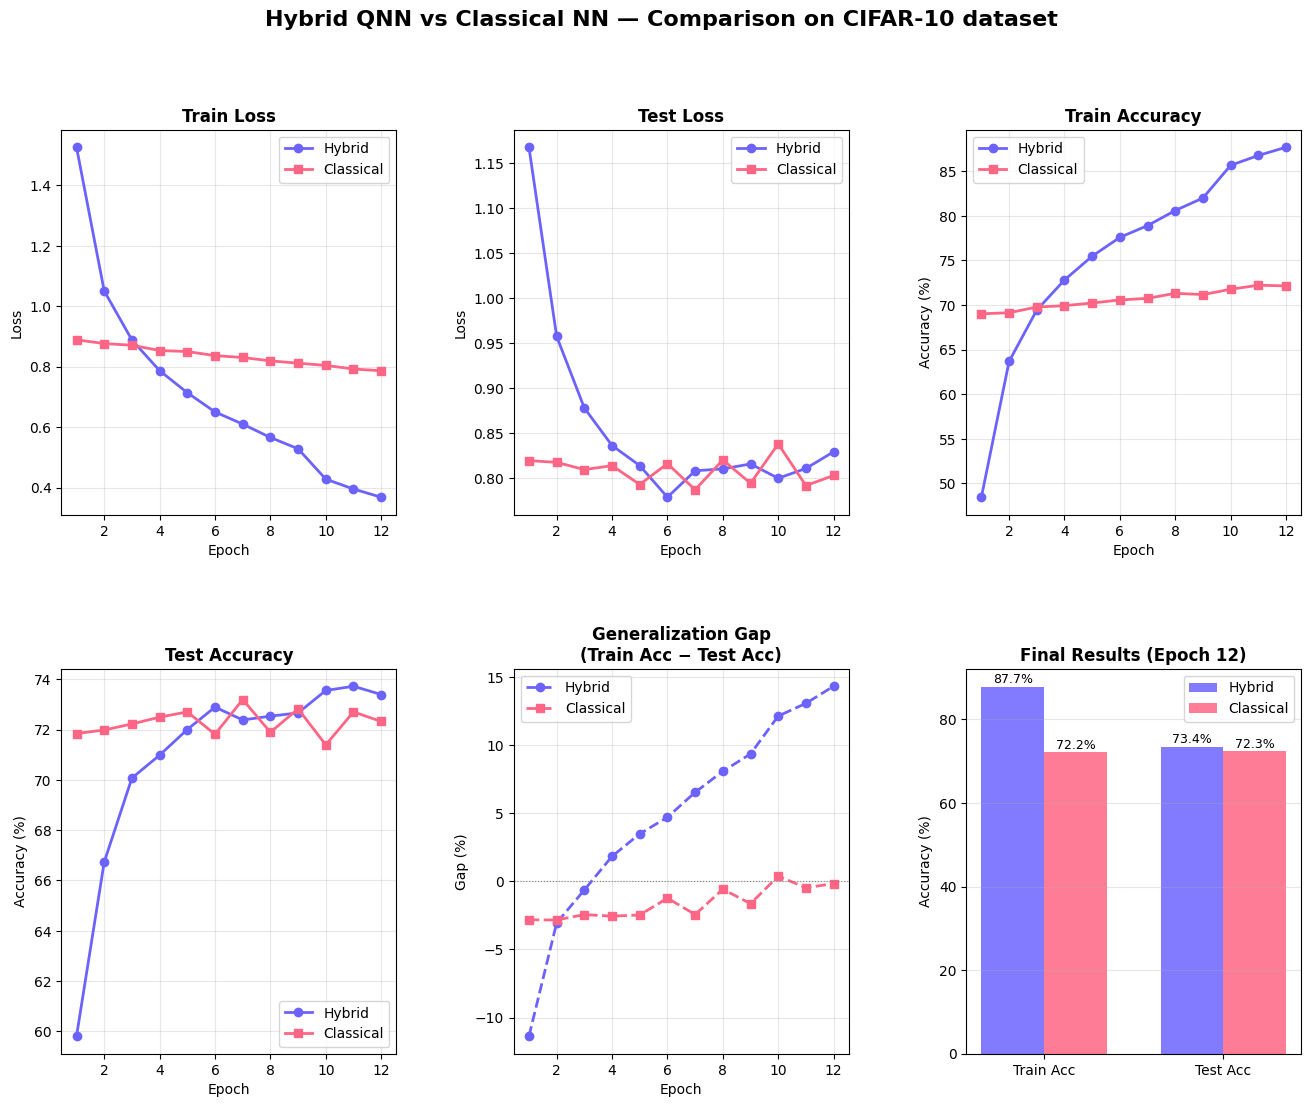


Plot saved as 'hybrid_vs_classical_cifar10.png'


In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
epochs = range(1, n_epoch + 1)

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Hybrid QNN vs Classical NN — Comparison on CIFAR-10 dataset',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = {'hybrid': '#6C63FF', 'classical': '#FF6584'}

# ── Plot 1: Train Loss ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history_cifar10['hybrid']['train_loss'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax1.plot(epochs, history_cifar10['classical']['train_loss'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax1.set_title('Train Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: Test Loss ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, history_cifar10['hybrid']['test_loss'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax2.plot(epochs, history_cifar10['classical']['test_loss'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax2.set_title('Test Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Plot 3: Train Accuracy ─────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, history_cifar10['hybrid']['train_acc'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax3.plot(epochs, history_cifar10['classical']['train_acc'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax3.set_title('Train Accuracy', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── Plot 4: Test Accuracy ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs, history_cifar10['hybrid']['test_acc'],    color=colors['hybrid'],    marker='o', linewidth=2, label='Hybrid')
ax4.plot(epochs, history_cifar10['classical']['test_acc'], color=colors['classical'], marker='s', linewidth=2, label='Classical')
ax4.set_title('Test Accuracy', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ── Plot 5: Generalization Gap ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
gap_hybrid    = [tr - te for tr, te in zip(history_cifar10['hybrid']['train_acc'],    history_cifar10['hybrid']['test_acc'])]
gap_classical = [tr - te for tr, te in zip(history_cifar10['classical']['train_acc'], history_cifar10['classical']['test_acc'])]
ax5.plot(epochs, gap_hybrid,    color=colors['hybrid'],    marker='o', linewidth=2, linestyle='--', label='Hybrid')
ax5.plot(epochs, gap_classical, color=colors['classical'], marker='s', linewidth=2, linestyle='--', label='Classical')
ax5.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax5.set_title('Generalization Gap\n(Train Acc − Test Acc)', fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Gap (%)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# ── Plot 6: Final Epoch Bar Chart ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
metrics     = ['Train Acc', 'Test Acc']
hybrid_vals = [history_cifar10['hybrid']['train_acc'][-1],    history_cifar10['hybrid']['test_acc'][-1]]
class_vals  = [history_cifar10['classical']['train_acc'][-1], history_cifar10['classical']['test_acc'][-1]]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax6.bar(x - width/2, hybrid_vals, width, label='Hybrid', color=colors['hybrid'], alpha=0.85)
bars2 = ax6.bar(x + width/2, class_vals,  width, label='Classical', color=colors['classical'], alpha=0.85)

ax6.set_title(f'Final Results (Epoch {n_epoch})', fontweight='bold')
ax6.set_ylabel('Accuracy (%)')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.savefig('hybrid_vs_classical_cifar10.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'hybrid_vs_classical_cifar10.png'")


In [48]:
hybrid_train_loss = history_cifar10['hybrid']['train_loss'][5:]
hybrid_test_loss  = history_cifar10['hybrid']['test_loss'][5:]
hybrid_train_acc  = history_cifar10['hybrid']['train_acc'][5:]
hybrid_test_acc   = history_cifar10['hybrid']['test_acc'][5:]
classical_train_loss = history_cifar10['classical']['train_loss'][5:]
classical_test_loss  = history_cifar10['classical']['test_loss'][5:]
classical_train_acc  = history_cifar10['classical']['train_acc'][5:]
classical_test_acc   = history_cifar10['classical']['test_acc'][5:]

In [51]:
print(len(history_cifar10['hybrid']['train_loss']))
print(len(history_cifar10['classical']['train_loss']))
print(len(history_cifar10['hybrid']['test_loss']))
print(len(history_cifar10['classical']['test_loss']))

17
53
17
53


In [50]:
print(len(history_cifar10['hybrid']['train_loss']))
print(len(history_cifar10['classical']['train_loss']))


17
53


In [30]:
import os
os .makedirs('save_models',exist_ok=True)

torch.save(model_hybrid_cifar10.state_dict(),'save_models/model_hybrid_cifar10.path')
torch.save(model_classic_cifar10.state_dict(),'save_models/model_classic_cifar10.path')



C:\Users\Acer\AppData\Local\Temp\ipykernel_21528\2115811609.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


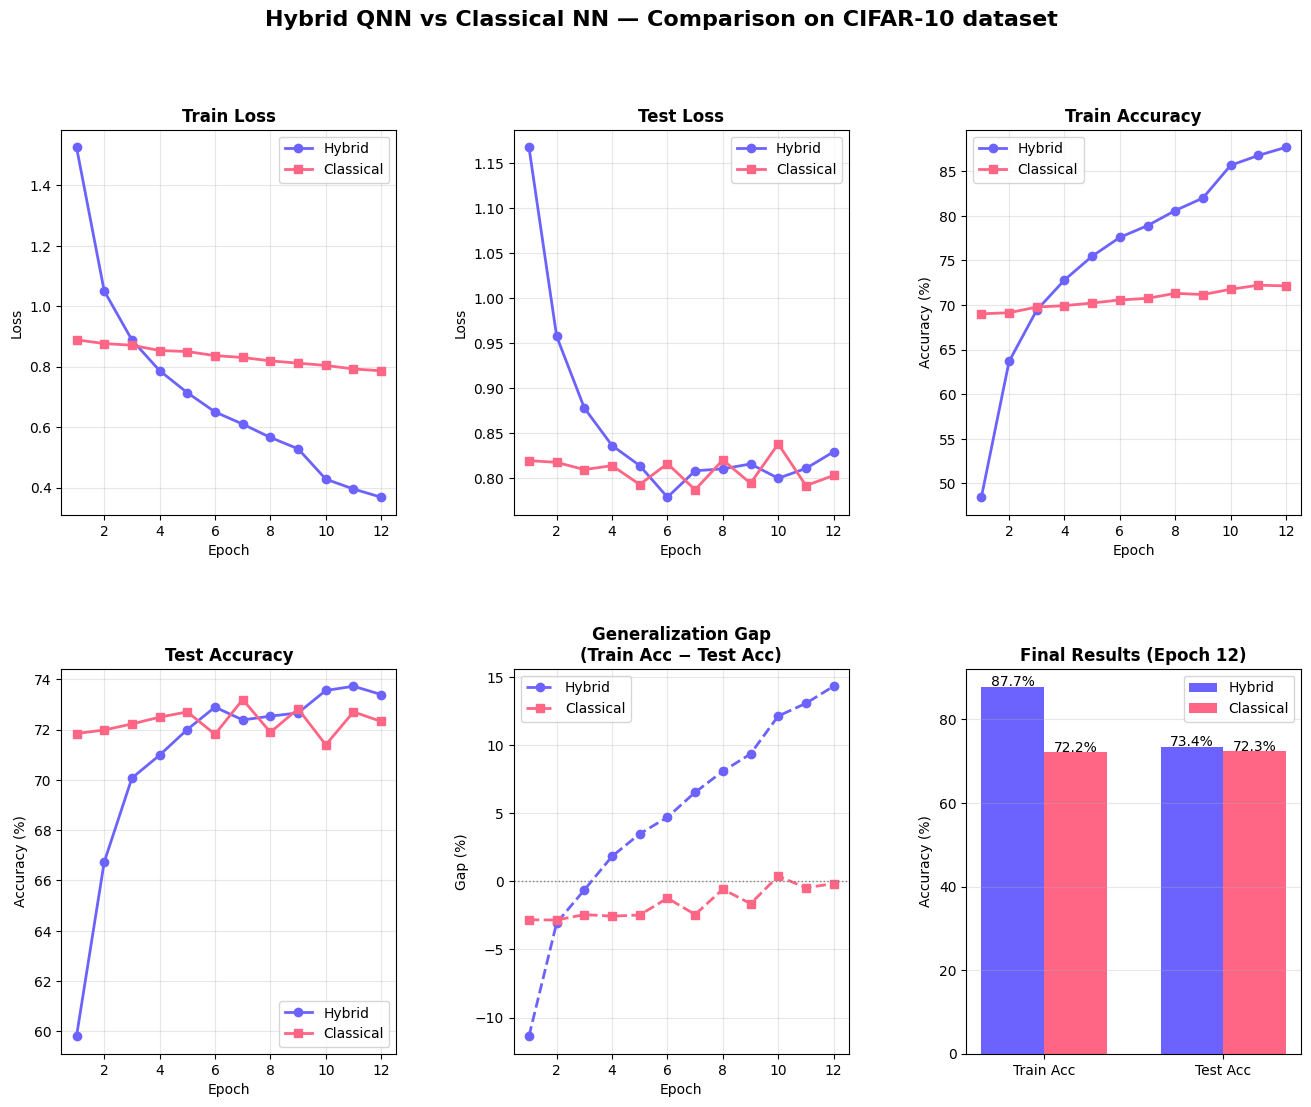

Saved: hybrid_vs_classical_cifar10_last12epochs.png


In [53]:
N = 12

for model in ['hybrid', 'classical']:
    for metric in ['train_loss', 'test_loss', 'train_acc', 'test_acc']:
        history_cifar10[model][metric] = history_cifar10[model][metric][-N:]

In [54]:
for model in ['hybrid', 'classical']:
    print(f"\n{model}")
    for metric in ['train_loss', 'test_loss', 'train_acc', 'test_acc']:
        print(metric, len(history_cifar10[model][metric]))


hybrid
train_loss 12
test_loss 12
train_acc 12
test_acc 12

classical
train_loss 12
test_loss 12
train_acc 12
test_acc 12


In [57]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

hy_total, hy_train = count_parameters(model_hybrid_cifar10)
cl_total, cl_train = count_parameters(model_classic_cifar10)

print(f"{'Model':<15}{'Total Params':>15}{'Trainable':>15}")
print("-"*45)
print(f"{'Hybrid':<15}{hy_total:>15,}{hy_train:>15,}")
print(f"{'Classical':<15}{cl_total:>15,}{cl_train:>15,}")

Model             Total Params      Trainable
---------------------------------------------
Hybrid                 101,954        101,954
Classical               55,834         55,834


In [60]:
print("="*60)
print("Hybrid Model")
print("="*60)
for name, p in model_hybrid_cifar10.named_parameters():
    print(f"{name:40} {str(tuple(p.shape)):20} {p.numel():10,}")

print("\n" + "="*60)
print("Classical Model")
print("="*60)
for name, p in model_classic_cifar10.named_parameters():
    print(f"{name:40} {str(tuple(p.shape)):20} {p.numel():10,}")

Hybrid Model
conv_block1.0.weight                     (32, 3, 3, 3)               864
conv_block1.0.bias                       (32,)                        32
conv_block1.1.weight                     (32,)                        32
conv_block1.1.bias                       (32,)                        32
conv_block2.0.weight                     (64, 32, 3, 3)           18,432
conv_block2.0.bias                       (64,)                        64
conv_block2.1.weight                     (64,)                        64
conv_block2.1.bias                       (64,)                        64
fc1.0.weight                             (20, 4096)               81,920
fc1.0.bias                               (20,)                        20
fc1.1.weight                             (20,)                        20
fc1.1.bias                               (20,)                        20
quantum_layer.circuts.0.weights          (3, 5, 3)                    45
quantum_layer.circuts.1.weights       